In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sklearn as skl
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error, zero_one_loss, accuracy_score


from copy import deepcopy

def entrenar_red(red: MLPClassifier | MLPRegressor,
                 super_epocas: int,
                 X_train, y_train,
                 X_val,   y_val,
                 X_test,  y_test):
    """
    Función que entrena una red ya definida previamente "super_epocas" veces,
    cada vez entrenando un número de épocas elegido al crear la red y midiendo
    el error en train, validación y test al terminar ese paso de entrenamiento.
    Guarda y devuelve la red en el paso de evaluación que da el mínimo error de
    validación.

    Argumentos:
      red: red neuronal predefinida
      evaluaciones (int): las veces que evalua
      X_{}: los conjuntos de valores de entrada de train, validación y test
      y_{}: los conjuntos de valores de salida o clase

    Salidas:
      red: la red entrenada en el mínimo de validación
      error_{}: los errores de: train, validación y test medidos en cada
        evaluación
    """
    error_train = []
    error_val = []
    error_test = []
    best_val = 1.0
    best_red = red

    for epoch in range(super_epocas):
      # red.partial_fit(X_train, y_train, classes=[0,1])
      ## Podríamos llamar partial_fit para realizar una sóla pasada a la vez,
      ## pero al ser muy costoso frenar y reanudar el entrenamiento realizamos
      ## varias épocas a la vez. Recordemos que la red fue definida con el
      ## parámetro 'sub-epocas', con lo cual cada llamado a 'fit' realiza esa
      ## cantidad de épocas
      red.fit(X_train, y_train)
      # error de training
      y_pred_train = red.predict(X_train)
      error_train.append(zero_one_loss(y_train, y_pred_train))
      # error de validacion
      y_pred_val = red.predict(X_val)
      cur_val = zero_one_loss(y_val, y_pred_val)
      error_val.append(cur_val)
      # error de test
      error_test.append(1 - red.score(X_test, y_test))
      if best_val > cur_val:
        best_val = cur_val
        best_red = deepcopy(red)
    return best_red, error_train, error_val, error_test


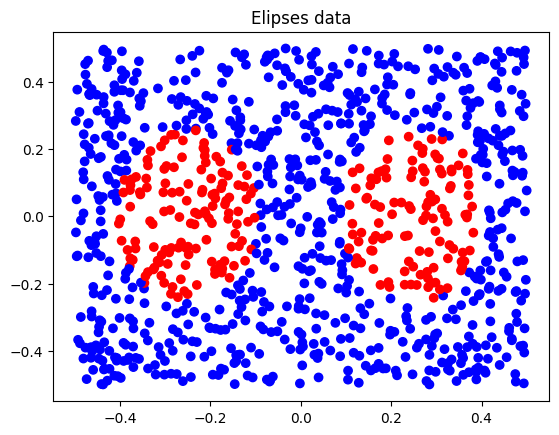

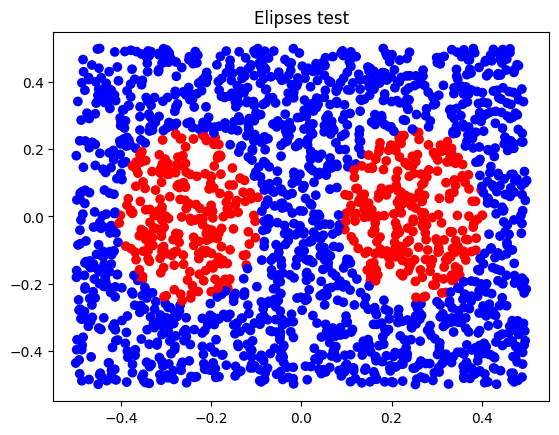

In [2]:
def cargar_csv(path, xcols=2):
    """
    Argumentos:
      path (str): ruta al archivo csv a cargar
      xcols (int): cantidad de columnas que representan las entradas,
        la columna restante representara la clase o dato de salida
    """
    df = pd.read_csv(path, header=None)
    X = df.loc[:, 0:(xcols-1)]
    y = df.loc[:, xcols]
    return X,y

def plot_elipses(data):
    p = data[0]
    c = data[1]

    plt.scatter(p[0], p[1], c=c, cmap="bwr")
    plt.show()

data = cargar_csv("dos_elipses.data")

plt.title("Elipses data")
plot_elipses(data)

test = cargar_csv("dos_elipses.test")
plt.title("Elipses test")
plot_elipses(test)

In [3]:
from joblib import Parallel, delayed
from IPython.display import display

N2 = 6              # neuronas en la capa oculta      
super_epocas = 300  # numero de epocas que entrena cada vez
sub_epocas = 50     # numero de veces que realizaremos sub-epocas


# Defino MLP para clasificación
def Classifier(eta, alfa, N2=N2, sub_epocas=sub_epocas):
    return MLPClassifier(
    hidden_layer_sizes=(N2,), activation='logistic', solver='sgd', alpha=0.0,
    batch_size=1, learning_rate='constant', learning_rate_init=eta,
    momentum=alfa, nesterovs_momentum=False, tol=0.0, warm_start=True,
    max_iter=sub_epocas
)

def train(eta, alfa):
   
    TRAINS = 10

    error = []


    # Elegir 500 valores del conjunto de data
    X_data,_,Y_data,_ = skl.model_selection.train_test_split(data[0].values.tolist(), data[1].values.tolist(), train_size=500)
    X_train, X_val, Y_train, Y_val = skl.model_selection.train_test_split(X_data,Y_data, train_size=400)

    # Elegir 2000 valores del conjunto de test
    # test ya tiene 2000 elementos
    X_test, Y_test = (test[0].values.tolist(), test[1].values.tolist())

    for i in range(TRAINS):
    
        cla = Classifier(eta=eta, alfa=alfa)

        best_fit, *_ = entrenar_red(cla,super_epocas,X_train,Y_train,X_val,Y_val,X_test,Y_test)
    
        error.append(1-best_fit.score(X_test, Y_test))

    print("Alfa: {}, Eta: {}\n{}\nError de test promedio: {}\n".format(alfa, eta, error, np.mean(error)*100))
    #print("Alfa:", alfa, "Eta:", eta)
    #print(error)
    #print("Error de test promedio:", np.mean(error)*100)
    #print("\n")


def train_wrapper(args):
    eta, alfa = args
    train(eta, alfa)

etas = [0.2, 0.3]
alfas = [0.2, 0.3]

params = [(eta, alfa) for eta in etas for alfa in alfas]
Parallel(n_jobs=-1)(delayed(train_wrapper)(p) for p in params)


TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

Detailed tracebacks of the workers should have been printed to stderr in the executor process if faulthandler was not disabled.